In [1]:
import time

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import scipy.special as sp_special

import elliptax
import elliptax.special as et_special

key = jr.key(time.time_ns())


def comp_plots(xs, y0s, y1s, colors, linesyles, labels1, labels2, title, logtop):
    _, axs = plt.subplots(2, 1, sharex=True, height_ratios=(3, 1), figsize=(10, 6))

    for x, y0, y1, color, linesyle, label1, label2 in zip(
        xs, y0s, y1s, colors, linesyles, labels1, labels2
    ):
        axs[0].plot(x, y0, color=color, linewidth=6, label=label1, alpha=0.5)
        axs[0].plot(x, y1, color="k", linestyle=linesyle, label=label2)
        if logtop:
            axs[0].set_yscale("log")
        axs[1].semilogy(x, jnp.abs(y0 - y1), ".", color=color, alpha=0.5)

    axs[0].legend(
        fontsize=11, ncol=len(xs), bbox_to_anchor=(0.5, 1.15), loc="lower center"
    )
    axs[0].set_title(title, fontsize=16)
    plt.show()

## Implementation using the real modulus `k`

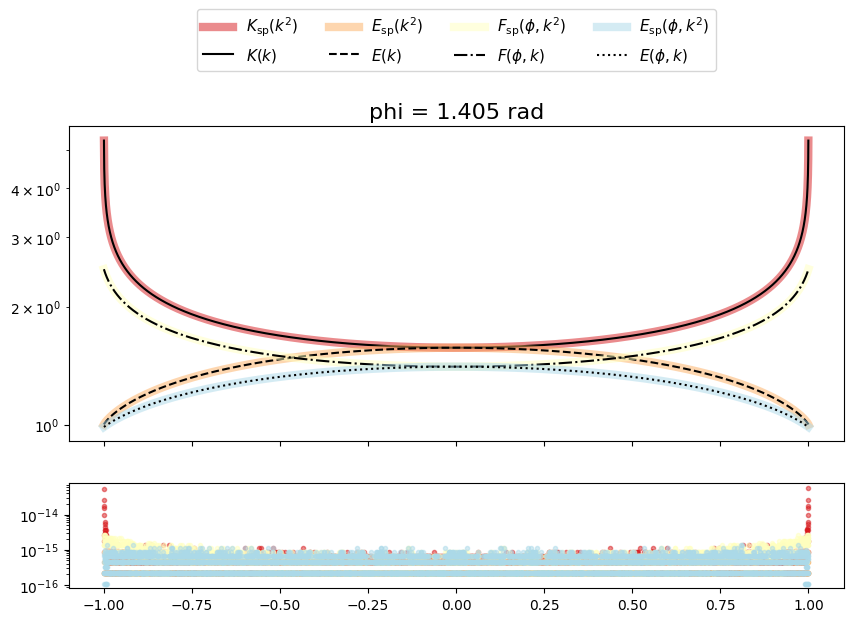

In [2]:
k = jnp.linspace(-1, 1, 10000)

key, skey = jr.split(key)
phi = jr.uniform(skey, (), minval=0, maxval=jnp.pi / 2)

comp_plots(
    4 * [k],
    [
        sp_special.ellipk(k * k),
        sp_special.ellipe(k * k),
        sp_special.ellipkinc(phi, k * k),
        sp_special.ellipeinc(phi, k * k),
    ],
    [
        elliptax.ellipk(k),
        elliptax.ellipe(k),
        elliptax.ellipfinc(phi, k),
        elliptax.ellipeinc(phi, k),
    ],
    ["#d7191c", "#fdae61", "#ffffbf", "#abd9e9"],
    ["-", "--", "-.", ":"],
    [
        r"$K_{\text{sp}}(k^2)$",
        r"$E_{\text{sp}}(k^2)$",
        r"$F_{\text{sp}}(\phi, k^2)$",
        r"$E_{\text{sp}}(\phi, k^2)$",
    ],
    [r"$K(k)$", r"$E(k)$", r"$F(\phi, k)$", r"$E(\phi, k)$"],
    f"phi = {phi:.3f} rad",
    True,
)

## Implementation using the square of the real modulus `m=k^2`

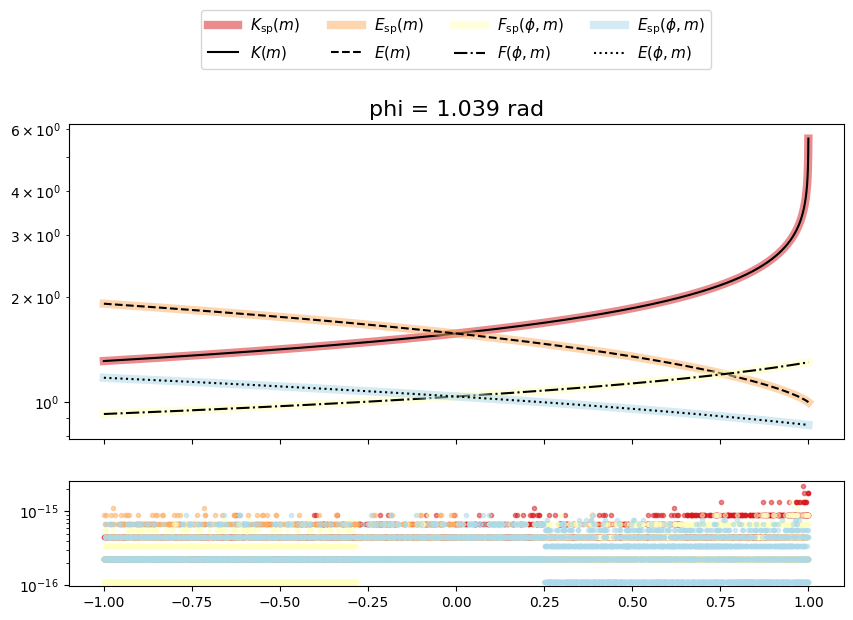

In [3]:
m = jnp.linspace(-1, 1, 10000)

key, skey = jr.split(key)
phi = jr.uniform(skey, (), minval=0, maxval=jnp.pi / 2)

comp_plots(
    4 * [m],
    [
        sp_special.ellipk(m),
        sp_special.ellipe(m),
        sp_special.ellipkinc(phi, m),
        sp_special.ellipeinc(phi, m),
    ],
    [
        et_special.ellipk(m),
        et_special.ellipe(m),
        et_special.ellipkinc(phi, m),
        et_special.ellipeinc(phi, m),
    ],
    ["#d7191c", "#fdae61", "#ffffbf", "#abd9e9"],
    ["-", "--", "-.", ":"],
    [
        r"$K_{\text{sp}}(m)$",
        r"$E_{\text{sp}}(m)$",
        r"$F_{\text{sp}}(\phi, m)$",
        r"$E_{\text{sp}}(\phi, m)$",
    ],
    [r"$K(m)$", r"$E(m)$", r"$F(\phi, m)$", r"$E(\phi, m)$"],
    f"phi = {phi:.3f} rad",
    True,
)

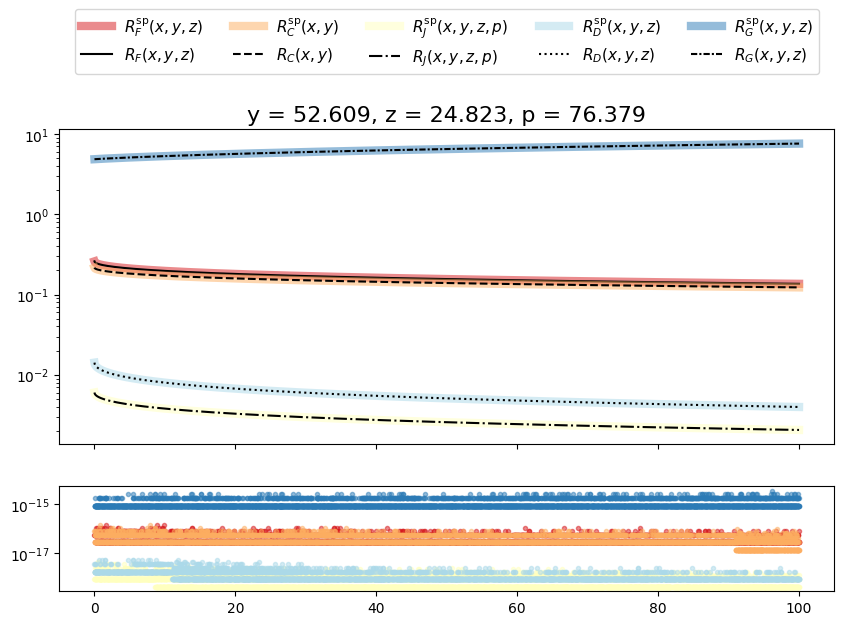

In [4]:
x = jnp.linspace(0, 100, 10000)
key, skey = jr.split(key)
y, z, p = jr.uniform(skey, (3,), minval=0, maxval=100)

comp_plots(
    5 * [x],
    [
        sp_special.elliprf(x, y, z),
        sp_special.elliprc(x, y),
        sp_special.elliprj(x, y, z, p),
        sp_special.elliprd(x, y, z),
        sp_special.elliprg(x, y, z),
    ],
    [
        et_special.elliprf(x, y, z),
        et_special.elliprc(x, y),
        et_special.elliprj(x, y, z, p),
        et_special.elliprd(x, y, z),
        et_special.elliprg(x, y, z),
    ],
    [
        "#d7191c",
        "#fdae61",
        "#ffffbf",
        "#abd9e9",
        "#2c7bb6",
    ],
    ["-", "--", "-.", ":", (0, (3, 1, 1, 1))],
    [
        r"$R_F^{\text{sp}}(x, y, z)$",
        r"$R_C^{\text{sp}}(x, y)$",
        r"$R_J^{\text{sp}}(x, y, z, p)$",
        r"$R_D^{\text{sp}}(x, y, z)$",
        r"$R_G^{\text{sp}}(x, y, z)$",
    ],
    [
        r"$R_F(x, y, z)$",
        r"$R_C(x, y)$",
        r"$R_J(x, y, z, p)$",
        r"$R_D(x, y, z)$",
        r"$R_G(x, y, z)$",
    ],
    f"y = {y:.3f}, z = {z:.3f}, p = {p:.3f}",
    True,
)